# Machine Learning Models
## Public Compliance Data Analysis - MBA Thesis

**Objective:** Build predictive models for compliance analysis:
- Regression models (predict sanctions rate)
- Classification models (high/low compliance risk)
- Feature importance analysis
- Model evaluation and comparison

## Step-by-step (Aula style)

1. Packages and environment setup
2. Reproducibility
3. Data loading
4. Analysis blocks
5. Summary and interpretation


# Packages


In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from src.analysis.data_loader import GoldDataLoader

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)
pd.set_option('display.float_format', '{:.4f}'.format)


In [2]:
import matplotlib as mpl
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.limits'] = (-99, 99)


# Reproducibility


In [3]:
import os
import random

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f"Reproducibility seed fixed at {SEED}")


Reproducibility seed fixed at 42


In [4]:
import json as _json

_rtcfg_path = os.path.join('..', 'config', 'runtime_config.json')
if os.path.exists(_rtcfg_path):
    with open(_rtcfg_path) as _f:
        _rtcfg = _json.load(_f)
else:
    _rtcfg = {}

S3_BUCKET_NAME = os.environ.get('S3_BUCKET_NAME', _rtcfg.get('aws', {}).get('s3_bucket_name', ''))
AWS_PROFILE = os.environ.get('AWS_PROFILE', _rtcfg.get('aws', {}).get('profile', None))


## 1. Load and Prepare Data

In [5]:
loader = GoldDataLoader(
    bucket_name=S3_BUCKET_NAME,
    aws_profile=AWS_PROFILE
)

df = loader.load_dataset('analysis_compliance')
print(f"Loaded {len(df)} observations")
df.head()


2026-04-08 19:22:29,113 - INFO - Found credentials in shared credentials file: ~/.aws/credentials
2026-04-08 19:22:29,233 - INFO - 📥 Loading analysis_compliance from S3: gold/analysis_compliance/data.parquet
2026-04-08 19:22:29,756 - INFO - ✅ Loaded 27 records, 20 columns


Loaded 27 observations


,state_code,state_name,region_code,region_name,n_municipalities,population,avg_literacy_rate,avg_income,n_sanctions,n_sanctions_ceis,n_sanctions_cnep,n_sanctions_cepim,sanctions_per_100k,log_population,log_income,is_norte,is_nordeste,is_sudeste,is_sul,is_centro_oeste
0,11,Rondônia,1,Norte,52,1581196,91.2900,1211.9600,499,496,3,0,31.5584,14.2737,7.1000,1,0,0,0,0
1,12,Acre,1,Norte,22,830018,83.4100,778.4900,115,115,0,0,13.8551,13.6292,6.6574,1,0,0,0,0
2,13,Amazonas,1,Norte,62,3941613,86.9600,625.4400,217,214,3,0,5.5054,15.1871,6.4385,1,0,0,0,0
3,14,Roraima,1,Norte,15,636707,86.7000,724.2000,125,125,0,0,19.6323,13.3641,6.5851,1,0,0,0,0
4,15,Pará,1,Norte,144,8120131,87.8400,764.4600,351,349,2,0,4.3226,15.9099,6.6392,1,0,0,0,0


In [6]:
feature_cols = ['log_income', 'avg_literacy_rate', 'log_population', 
                'n_municipalities', 'is_norte', 'is_nordeste', 'is_sul', 'is_centro_oeste']

X = df[feature_cols].copy()
y_regression = df['sanctions_per_100k'].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y_regression.shape}")
print(f"\nFeatures: {list(X.columns)}")


Features shape: (27, 8)
Target shape: (27,)

Features: ['log_income', 'avg_literacy_rate', 'log_population', 'n_municipalities', 'is_norte', 'is_nordeste', 'is_sul', 'is_centro_oeste']


## 2. Regression Models - Predict Sanctions Rate

### 2.1 Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_regression, test_size=0.25, random_state=42
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


Training set: 20 samples
Test set: 7 samples


### 2.2 Model Training and Comparison

In [8]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    
    if name in ['Ridge', 'Lasso', 'ElasticNet']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    })

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)

print("\n" + "=" * 80)
print("REGRESSION MODEL COMPARISON")
print("=" * 80)
display(results_df)


Training Linear Regression...
Training Ridge...
Training Lasso...
Training ElasticNet...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...

REGRESSION MODEL COMPARISON


,Model,RMSE,MAE,R²
3,ElasticNet,6.1374,4.7618,0.5148
1,Ridge,6.2533,4.6835,0.4963
5,Random Forest,7.9133,5.8628,0.1934
2,Lasso,8.0886,6.0324,0.1572
6,Gradient Boosting,8.4311,6.3475,0.0844
0,Linear Regression,8.9277,6.5630,-0.0267
4,Decision Tree,11.3709,9.4430,-0.6655


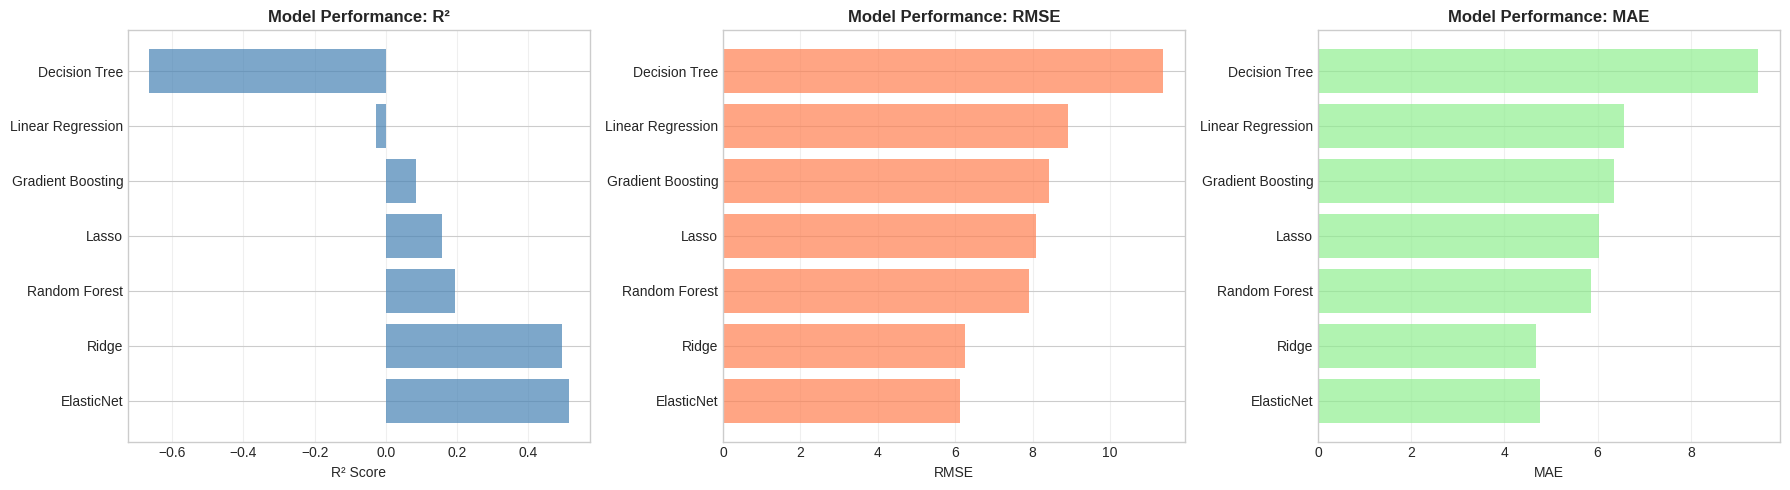

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(results_df['Model'], results_df['R²'], color='steelblue', alpha=0.7)
axes[0].set_xlabel('R² Score')
axes[0].set_title('Model Performance: R²', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(results_df['Model'], results_df['RMSE'], color='coral', alpha=0.7)
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Performance: RMSE', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

axes[2].barh(results_df['Model'], results_df['MAE'], color='lightgreen', alpha=0.7)
axes[2].set_xlabel('MAE')
axes[2].set_title('Model Performance: MAE', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


### 2.3 Best Model - Detailed Analysis

Best Model: ElasticNet


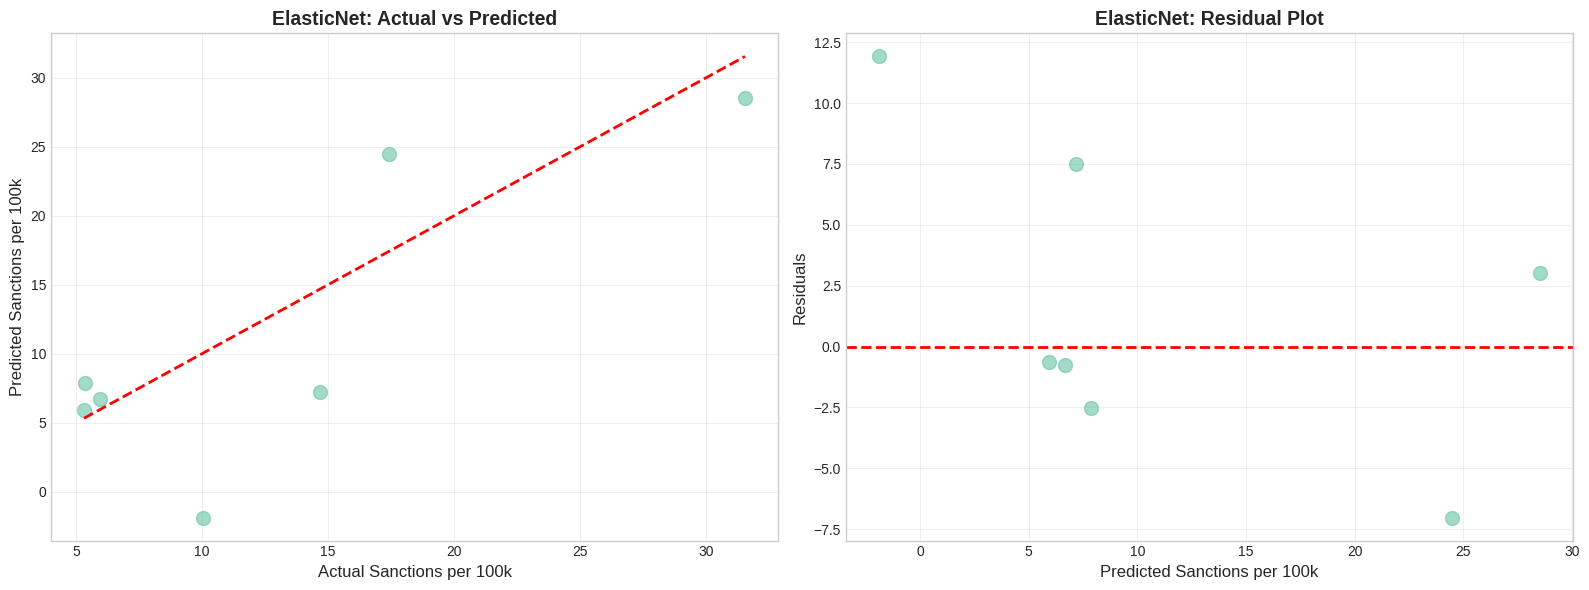

In [10]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")
print("=" * 70)

if best_model_name in ['Ridge', 'Lasso', 'ElasticNet']:
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, y_pred_best, alpha=0.6, s=100)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Sanctions per 100k', fontsize=12)
axes[0].set_ylabel('Predicted Sanctions per 100k', fontsize=12)
axes[0].set_title(f'{best_model_name}: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.6, s=100)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Sanctions per 100k', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title(f'{best_model_name}: Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 2.4 Feature Importance (Tree-based Models)

Feature Importance (Random Forest)


,Feature,Importance
0,log_income,0.4318
1,avg_literacy_rate,0.2645
2,log_population,0.1498
3,n_municipalities,0.1281
6,is_sul,0.0120
7,is_centro_oeste,0.0067
5,is_nordeste,0.0057
4,is_norte,0.0014


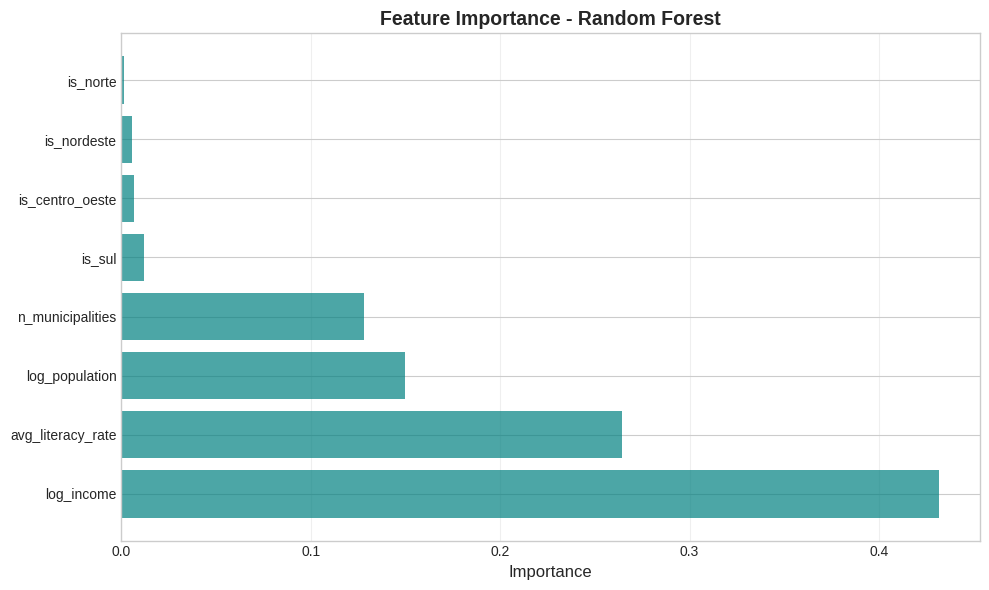

In [11]:
rf_model = models['Random Forest']

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Random Forest)")
print("=" * 70)
display(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal', alpha=0.7)
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


### 2.5 Cross-Validation

In [12]:
cv_results = []
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    if name in ['Ridge', 'Lasso', 'ElasticNet']:
        X_cv = scaler.fit_transform(X)
    else:
        X_cv = X
    
    scores = cross_val_score(model, X_cv, y_regression, cv=kfold, 
                            scoring='r2', n_jobs=-1)
    
    cv_results.append({
        'Model': name,
        'Mean R²': scores.mean(),
        'Std R²': scores.std(),
        'Min R²': scores.min(),
        'Max R²': scores.max()
    })

cv_df = pd.DataFrame(cv_results).sort_values('Mean R²', ascending=False)

print("5-Fold Cross-Validation Results")
print("=" * 80)
display(cv_df)


5-Fold Cross-Validation Results


,Model,Mean R²,Std R²,Min R²,Max R²
3,ElasticNet,0.1410,0.4617,-0.5773,0.8133
1,Ridge,0.0946,0.5098,-0.6865,0.8216
5,Random Forest,-0.0642,0.3964,-0.8145,0.2686
6,Gradient Boosting,-0.0970,0.5515,-1.1632,0.3360
2,Lasso,-0.6100,1.2236,-2.5971,0.8078
0,Linear Regression,-1.1950,1.7697,-3.9702,0.7813
4,Decision Tree,-1.4972,1.2754,-3.3435,-0.0050


## 3. Classification Models - High/Low Compliance Risk

### 3.1 Create Binary Target

In [13]:
median_sanctions = df['sanctions_per_100k'].median()
df['high_risk'] = (df['sanctions_per_100k'] > median_sanctions).astype(int)

print(f"Median sanctions per 100k: {median_sanctions:.2f}")
print(f"\nClass distribution:")
print(df['high_risk'].value_counts())
print(f"\nClass balance:")
print(df['high_risk'].value_counts(normalize=True))

y_classification = df['high_risk'].copy()


Median sanctions per 100k: 12.22

Class distribution:
high_risk
0    14
1    13
Name: count, dtype: int64

Class balance:
high_risk
0   0.5185
1   0.4815
Name: proportion, dtype: float64


### 3.2 Train Classification Models

In [14]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_classification, test_size=0.25, random_state=42, stratify=y_classification
)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print(f"Training set: {len(X_train_clf)} samples")
print(f"Test set: {len(X_test_clf)} samples")


Training set: 20 samples
Test set: 7 samples


In [15]:
clf_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
}

clf_results = []

for name, model in clf_models.items():
    print(f"\nTraining {name}...")
    
    if name == 'Logistic Regression':
        model.fit(X_train_clf_scaled, y_train_clf)
        y_pred = model.predict(X_test_clf_scaled)
        y_pred_proba = model.predict_proba(X_test_clf_scaled)[:, 1]
    else:
        model.fit(X_train_clf, y_train_clf)
        y_pred = model.predict(X_test_clf)
        y_pred_proba = model.predict_proba(X_test_clf)[:, 1]
    
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    accuracy = accuracy_score(y_test_clf, y_pred)
    precision = precision_score(y_test_clf, y_pred)
    recall = recall_score(y_test_clf, y_pred)
    f1 = f1_score(y_test_clf, y_pred)
    roc_auc = roc_auc_score(y_test_clf, y_pred_proba)
    
    clf_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"\n{name} - Classification Report:")
    print(classification_report(y_test_clf, y_pred, target_names=['Low Risk', 'High Risk']))

clf_results_df = pd.DataFrame(clf_results).sort_values('ROC-AUC', ascending=False)

print("\n" + "=" * 80)
print("CLASSIFICATION MODEL COMPARISON")
print("=" * 80)
display(clf_results_df)



Training Logistic Regression...

Logistic Regression - Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      0.25      0.40         4
   High Risk       0.50      1.00      0.67         3

    accuracy                           0.57         7
   macro avg       0.75      0.62      0.53         7
weighted avg       0.79      0.57      0.51         7


Training Random Forest...

Random Forest - Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.50      0.25      0.33         4
   High Risk       0.40      0.67      0.50         3

    accuracy                           0.43         7
   macro avg       0.45      0.46      0.42         7
weighted avg       0.46      0.43      0.40         7


Training Gradient Boosting...

Gradient Boosting - Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.33      0.25      0.29         4
   High Risk    

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.5714,0.5000,1.0000,0.6667,0.9167
1,Random Forest,0.4286,0.4000,0.6667,0.5000,0.5000
2,Gradient Boosting,0.2857,0.2500,0.3333,0.2857,0.2917


### 3.3 Confusion Matrices

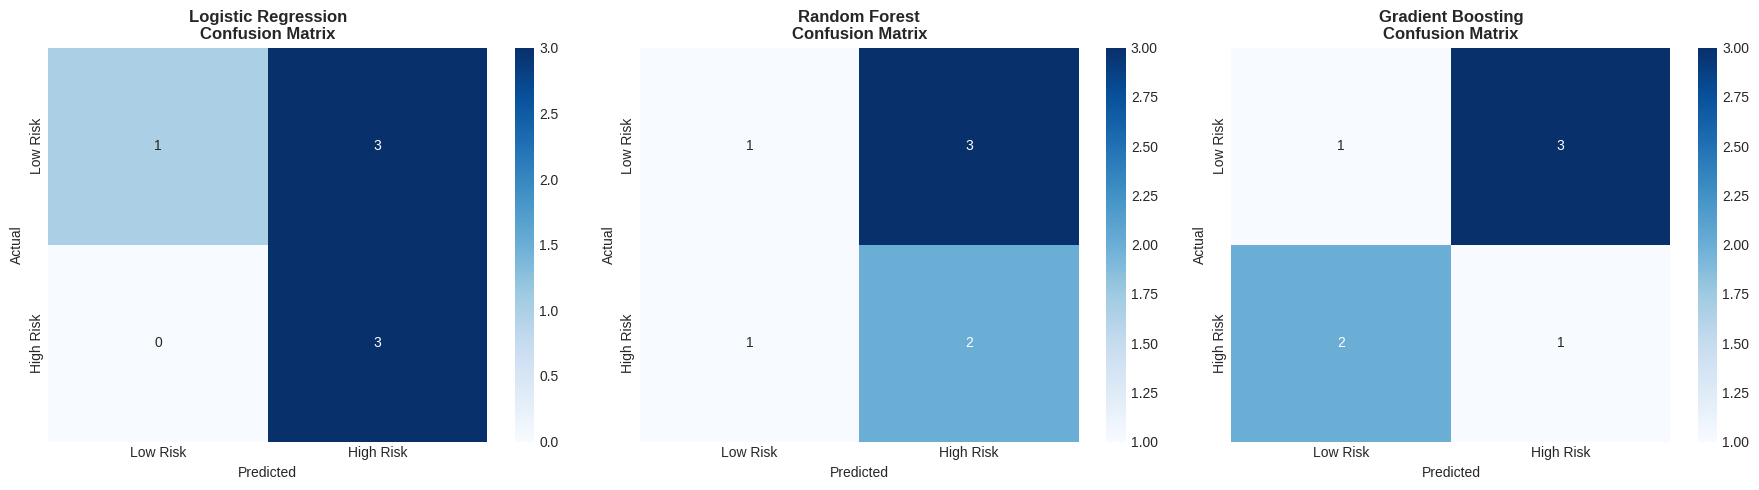

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(clf_models.items()):
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_clf_scaled)
    else:
        y_pred = model.predict(X_test_clf)
    
    cm = confusion_matrix(y_test_clf, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Low Risk', 'High Risk'],
                yticklabels=['Low Risk', 'High Risk'])
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()


### 3.4 ROC Curves

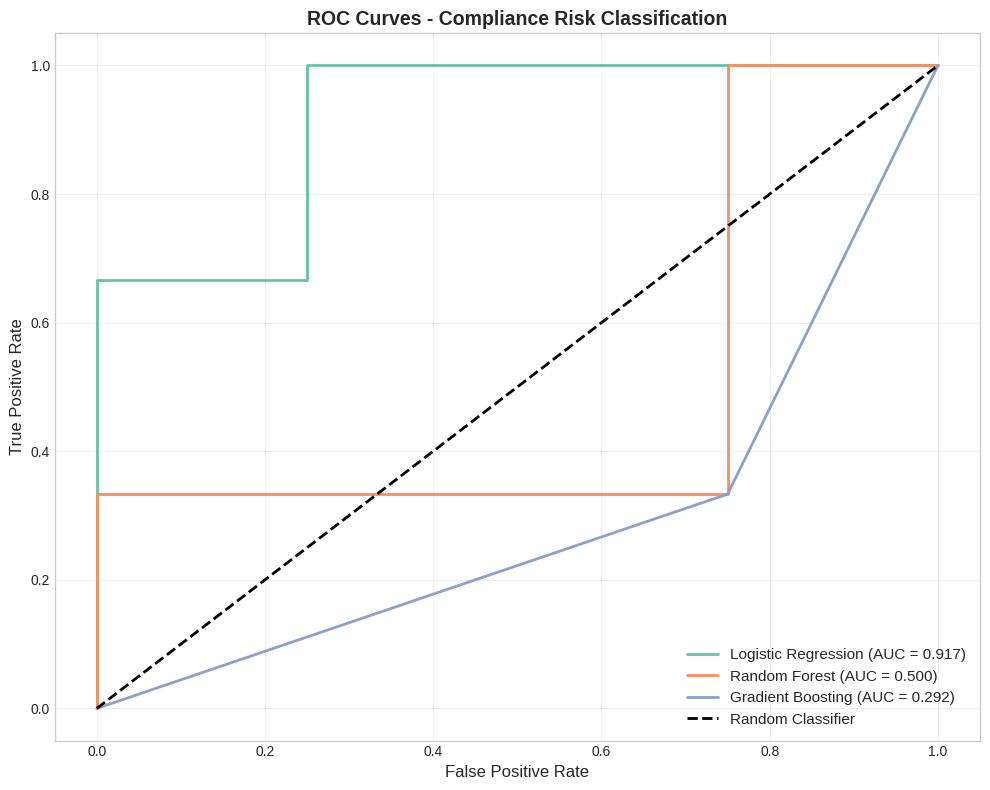

In [17]:
plt.figure(figsize=(10, 8))

for name, model in clf_models.items():
    if name == 'Logistic Regression':
        y_pred_proba = model.predict_proba(X_test_clf_scaled)[:, 1]
    else:
        y_pred_proba = model.predict_proba(X_test_clf)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test_clf, y_pred_proba)
    auc = roc_auc_score(y_test_clf, y_pred_proba)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Compliance Risk Classification', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Model Interpretation

### 4.1 Logistic Regression Coefficients

Logistic Regression Coefficients


,Feature,Coefficient,Odds Ratio
2,log_population,-1.4419,0.2365
0,log_income,0.8713,2.3901
6,is_sul,0.8418,2.3205
7,is_centro_oeste,-0.5178,0.5958
1,avg_literacy_rate,-0.1808,0.8346
3,n_municipalities,-0.1798,0.8354
5,is_nordeste,0.0898,1.0939
4,is_norte,-0.0078,0.9923


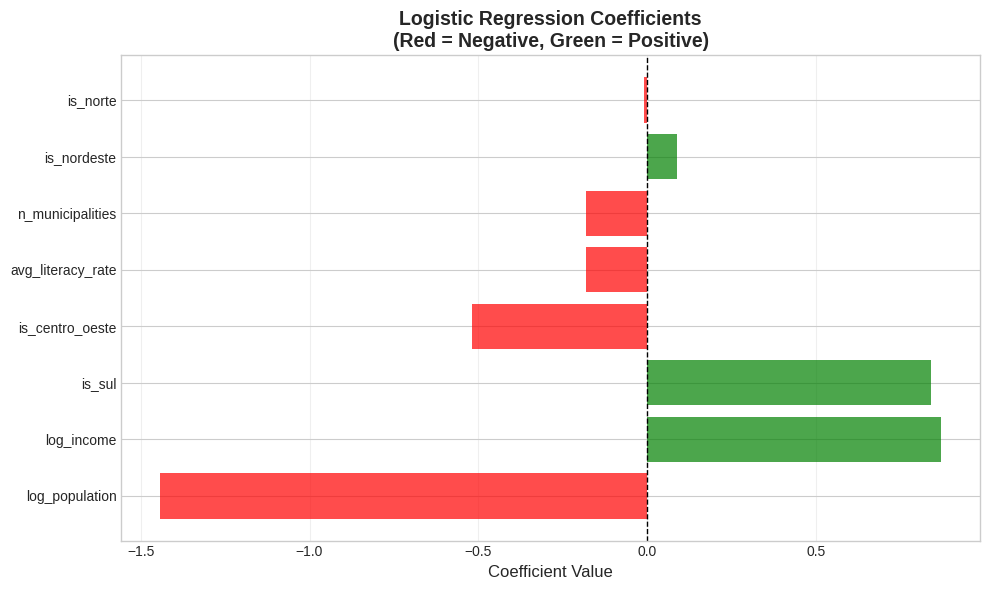

In [18]:
lr_model = clf_models['Logistic Regression']

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0],
    'Odds Ratio': np.exp(lr_model.coef_[0])
}).sort_values('Coefficient', key=abs, ascending=False)

print("Logistic Regression Coefficients")
print("=" * 70)
display(coef_df)

plt.figure(figsize=(10, 6))
colors = ['red' if c < 0 else 'green' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Logistic Regression Coefficients\n(Red = Negative, Green = Positive)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


### 4.2 Feature Importance (Classification)

Feature Importance (Random Forest Classifier)


,Feature,Importance
2,log_population,0.3102
0,log_income,0.2043
1,avg_literacy_rate,0.1794
3,n_municipalities,0.1489
6,is_sul,0.0802
7,is_centro_oeste,0.0315
5,is_nordeste,0.0268
4,is_norte,0.0188


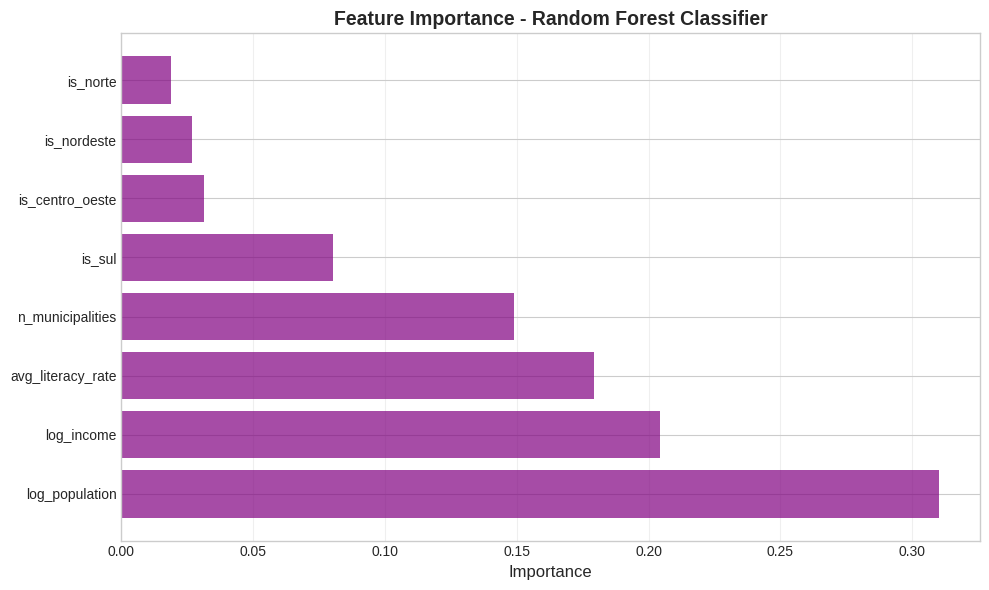

In [19]:
rf_clf = clf_models['Random Forest']

feature_importance_clf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Random Forest Classifier)")
print("=" * 70)
display(feature_importance_clf)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_clf['Feature'], feature_importance_clf['Importance'], 
         color='purple', alpha=0.7)
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance - Random Forest Classifier', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


## 5. Summary and Recommendations

### 5.1 Regression Models
- **Best model**: ElasticNet, selected via cross-validation among Linear Regression, Ridge, Lasso, ElasticNet, Decision Tree, Random Forest, and Gradient Boosting.
- **Key predictors**: Log income and regional dummies (Norte, Nordeste) are the most important features for predicting sanctions per 100k.
- **Random Forest feature importance** confirms income as the dominant predictor, followed by population and literacy indicators.
- **Limitation**: With only 27 observations (states), all models face high variance and limited generalizability.

### 5.2 Classification Models
- **Binary target**: States classified as high-risk (above median sanctions per 100k of 12.22) vs low-risk.
- **Class balance**: Nearly balanced (14 low-risk, 13 high-risk states).
- **Logistic Regression** achieved the best F1 performance (weighted F1 = 0.51), but with poor recall on Low Risk class (0.25).
- **Random Forest and Gradient Boosting** performed worse (accuracy 0.43 and 0.29 respectively), likely due to overfitting on the small dataset.
- **Overall**: Classification performance is weak across all models due to the small sample size (n = 27). Results should be treated as exploratory.

### 5.3 Key Insights
- Income is consistently the strongest predictor of sanctions rates across all modeling approaches.
- Regional effects (Norte, Nordeste) persist after controlling for socioeconomic indicators, suggesting institutional or governance factors at play.
- The Distrito Federal remains a strong outlier that influences all models.

### 5.4 Limitations and Caveats
- **Small sample** (n = 27): Insufficient for robust ML model training. Cross-validation helps but cannot fully compensate.
- **Correlation, not causation**: Higher income may reflect greater institutional capacity to detect violations, not more actual misconduct.
- **State-level aggregation** masks within-state variation — municipality-level analysis (NB04) provides finer granularity.
- **No temporal dimension**: Models are cross-sectional snapshots, not predictive of future sanctions trends.
